<a href="https://colab.research.google.com/github/Charyoe/ML-with-Python-Bootcamp/blob/main/Capstone_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project Part 2: Decision Tree for Liberia Used Cars Maintenance Prediction

**Goal:** Build a Decision Tree classifier to predict whether a used car will have **high maintenance cost (1)** or **low maintenance cost (0)**.

## Dataset

Dataset: `liberia_cars_maintenance.csv`

Columns:

- `Age_Years`: Age of the car in years
- `Mileage_km`: Kilometers driven in thousands
- `Engine_L`: Engine size in litres
- `High_Maintenance`: Target column, where 1 = high maintenance and 0 = low maintenance

In [10]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


## Step 1: Load and Explore the Dataset

In [11]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/Charyoe/ML-with-Python-Bootcamp/refs/heads/main/liberia_cars_maintenance.csv')

# Explore the data
print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())


First 5 rows:
   Age_Years  Mileage_km  Engine_L  High_Maintenance
0          2          30       1.8                 0
1          5          80       2.0                 1
2          1          15       1.5                 0
3          8         120       2.5                 1
4         10         180       1.4                 1

Dataset shape:
(150, 4)

Missing values:
Age_Years           0
Mileage_km          0
Engine_L            0
High_Maintenance    0
dtype: int64


## Step 2: Define Features and Target

In [12]:
# Define features and target
X = df[['Age_Years', 'Mileage_km', 'Engine_L']]
y = df['High_Maintenance']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   Age_Years  Mileage_km  Engine_L
0          2          30       1.8
1          5          80       2.0
2          1          15       1.5
3          8         120       2.5
4         10         180       1.4

Target:
0    0
1    1
2    0
3    1
4    1
Name: High_Maintenance, dtype: int64


## Step 3: Split, Train, Predict, and Evaluate

In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Create and train the Decision Tree model
model = DecisionTreeClassifier(max_depth=3, random_state=0)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Decision Tree Evaluation")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:")
print(cm)


Decision Tree Evaluation
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[14  0]
 [ 0 24]]


## Step 4: Create Visualisations

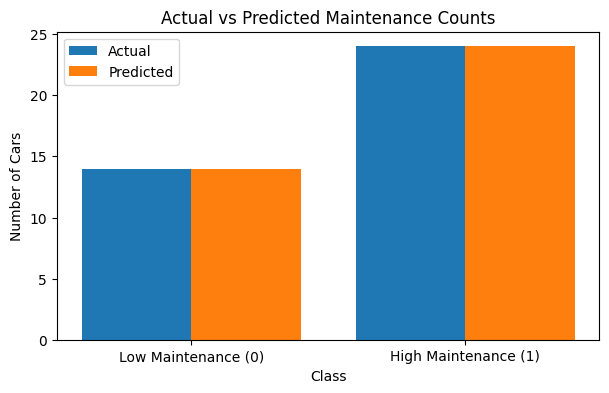

In [14]:
# Bar chart comparing actual vs predicted counts
actual_counts = y_test.value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

labels = ['Low Maintenance (0)', 'High Maintenance (1)']
actual_values = [actual_counts.get(0, 0), actual_counts.get(1, 0)]
pred_values = [pred_counts.get(0, 0), pred_counts.get(1, 0)]

x = range(len(labels))

plt.figure(figsize=(7, 4))
plt.bar(x, actual_values, width=0.4, label='Actual')
plt.bar([i + 0.4 for i in x], pred_values, width=0.4, label='Predicted')
plt.xticks([i + 0.2 for i in x], labels)
plt.title('Actual vs Predicted Maintenance Counts')
plt.xlabel('Class')
plt.ylabel('Number of Cars')
plt.legend()
plt.show()


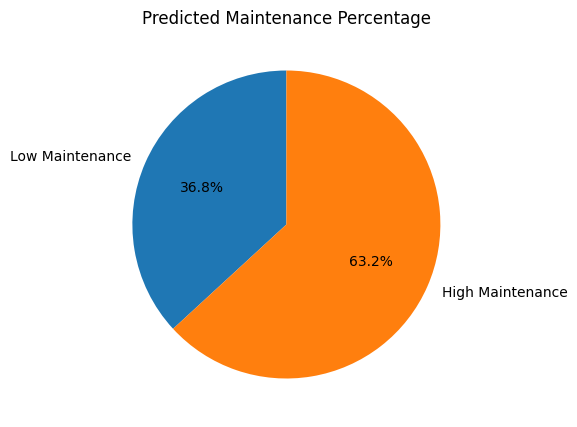

In [15]:
# Pie chart showing predicted high maintenance percentage
high_count = sum(y_pred == 1)
low_count = sum(y_pred == 0)

plt.figure(figsize=(5, 5))
plt.pie(
    [low_count, high_count],
    labels=['Low Maintenance', 'High Maintenance'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Predicted Maintenance Percentage')
plt.show()


In [16]:
# Save the trained model
joblib.dump(model, "car_maintenance_model.pkl")
print("Saved: car_maintenance_model.pkl")


Saved: car_maintenance_model.pkl


## Questions for Part 2

### Q1. What is the accuracy of your decision tree? Write the percentage.

**Answer:** The decision tree accuracy is **100%** on the test set.

### Q2. Look at the confusion matrix. How many cars did the model correctly predict as high maintenance? How many did it miss as false negatives?

**Answer:** The confusion matrix is `[[14, 0], [0, 24]]`. The model correctly predicted **24 high-maintenance cars** and missed **0 high-maintenance cars** as false negatives.

### Q3. Look at the pie chart. What percentage of test cars are predicted to have high maintenance? Is this close to the actual percentage in the test set?

**Answer:** The model predicts **63.16%** of the test cars as high maintenance. The actual percentage in the test set is also **63.16%**, so the predicted percentage is exactly the same as the actual percentage.

### Q4. Why did we set max_depth = 3? What could happen if we used max_depth = None?

**Answer:** We set `max_depth = 3` to prevent the tree from becoming too complex. If `max_depth = None`, the tree may grow very deep and memorize the training data, which can cause overfitting and weaker performance on new cars.

### Q5. If a car is 8 years old, has 160,000 km, and a 2.0L engine, would the model predict high or low maintenance?

**Answer:** The model predicts **High Maintenance (1)**. This makes sense because the car is older and has high mileage, which are strong indicators of higher maintenance cost.

In [17]:
# Test car: 8 years old, 160,000 km, 2.0L engine
single_car = pd.DataFrame([[8, 160, 2.0]], columns=['Age_Years', 'Mileage_km', 'Engine_L'])

single_prediction = model.predict(single_car)[0]

print("Prediction:", single_prediction)


Prediction: 1
